# U.S. Chronic Disease Indicators — Exploratory Data Analysis & Predictive Modeling

**Dataset:** CDC U.S. Chronic Disease Indicators (CDI) — `U_S__Chronic_Disease_Indicators.csv`
**Rows:** 398,793 | **Columns:** 34 | **Coverage:** 2015–2023, 55 U.S. states/territories

**Goal:** Explore the dataset, define a clean modeling subset, and build a regression model
that predicts a chronic disease indicator's **Crude Prevalence (%)** from contextual
features (location, year, topic, question, demographic stratification).

**Notebook structure**
1. Imports & Setup
2. Data Loading & Initial Inspection
3. Exploratory Data Analysis (raw data)
4. Data Quality Assessment & Modeling Scope
5. Feature Engineering
6. Target Definition & Train/Test Split (leak-free outlier handling demo)
7. Preprocessing Pipeline
8. Model Selection (baseline comparison)
9. Model Evaluation
10. Hyperparameter Tuning
11. Feature Importance
12. Final Model & Diagnostics
13. Model Persistence
14. Example Predictions
15. Summary


## 1. Imports & Setup

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
pd.set_option('display.max_columns', 40)


## 2. Data Loading & Initial Inspection

We load the raw CSV and take a first look at its shape, columns, and data types.
This dataset is in **long format**: each row is one indicator value for one
location/year/demographic slice, so many columns are only populated for certain
kinds of rows (e.g. `Response` is used for a small subset of indicators only).


In [10]:
df_raw = pd.read_csv('U.S._Chronic_Disease_Indicators.csv', low_memory=False)
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (398793, 34)


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,AR,Arkansas,NVSS,Asthma,"Asthma mortality among all people, underlying ...",NaN,Number,Number,20.0,20.0,NaN,NaN,NaN,NaN,Sex,Female,NaN,NaN,NaN,NaN,POINT (-92.27449074 34.74865012400045),5,AST,AST01,NaN,NMBR,SEX,SEXF,NaN,NaN,NaN,NaN
1,2019,2019,IA,Iowa,NVSS,Asthma,"Asthma mortality among all people, underlying ...",NaN,Number,Number,32.0,32.0,NaN,NaN,NaN,NaN,Sex,Female,NaN,NaN,NaN,NaN,POINT (-93.81649056 42.46940091300047),19,AST,AST01,NaN,NMBR,SEX,SEXF,NaN,NaN,NaN,NaN
2,2021,2021,CO,Colorado,BRFSS,Asthma,Current asthma among adults,NaN,%,Crude Prevalence,8.1,8.1,NaN,NaN,7.2,9.0,Sex,Male,NaN,NaN,NaN,NaN,POINT (-106.1336109 38.843840757000464),8,AST,AST02,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
3,2023,2023,KY,Kentucky,BRFSS,Asthma,Current asthma among adults,NaN,%,Crude Prevalence,NaN,NaN,*,No data available,NaN,NaN,Age,Age >=65,NaN,NaN,NaN,NaN,POINT (-84.77497105 37.645970271000465),21,AST,AST02,NaN,CRDPREV,AGE,AGE65P,NaN,NaN,NaN,NaN
4,2023,2023,MD,Maryland,BRFSS,Asthma,Current asthma among adults,NaN,%,Crude Prevalence,10.1,10.1,NaN,NaN,8.8,11.6,Age,Age >=65,NaN,NaN,NaN,NaN,POINT (-76.60926011 39.29058096400047),24,AST,AST02,NaN,CRDPREV,AGE,AGE65P,NaN,NaN,NaN,NaN


In [11]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398793 entries, 0 to 398792
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  398793 non-null  int64  
 1   YearEnd                    398793 non-null  int64  
 2   LocationAbbr               398793 non-null  object 
 3   LocationDesc               398793 non-null  object 
 4   DataSource                 398793 non-null  object 
 5   Topic                      398793 non-null  object 
 6   Question                   398793 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              398793 non-null  object 
 9   DataValueType              398793 non-null  object 
 10  DataValue                  272036 non-null  float64
 11  DataValueAlt               272036 non-null  float64
 12  DataValueFootnoteSymbol    128750 non-null  object 
 13  DataValueFootnote          12

In [12]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YearStart,398793.0,NaN,NaN,NaN,2020.517559,1.768041,2015.0,2019.0,2021.0,2022.0,2023.0
YearEnd,398793.0,NaN,NaN,NaN,2020.794926,1.359337,2019.0,2020.0,2021.0,2022.0,2023.0
LocationAbbr,398793,55,US,7479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LocationDesc,398793,55,United States,7479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DataSource,398793,14,BRFSS,245700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topic,398793,19,Cardiovascular Disease,42636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Question,398793,108,"Asthma mortality among all people, underlying ...",7488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Response,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DataValueUnit,398793,8,%,260711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DataValueType,398793,12,Crude Prevalence,165341,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (Raw Data)

Before deciding on a modeling scope, let's understand the shape of the data:
missingness, cardinality, and how values are distributed across different
`DataValueType`/`DataValueUnit` combinations.


### 3.1 Missing values by column

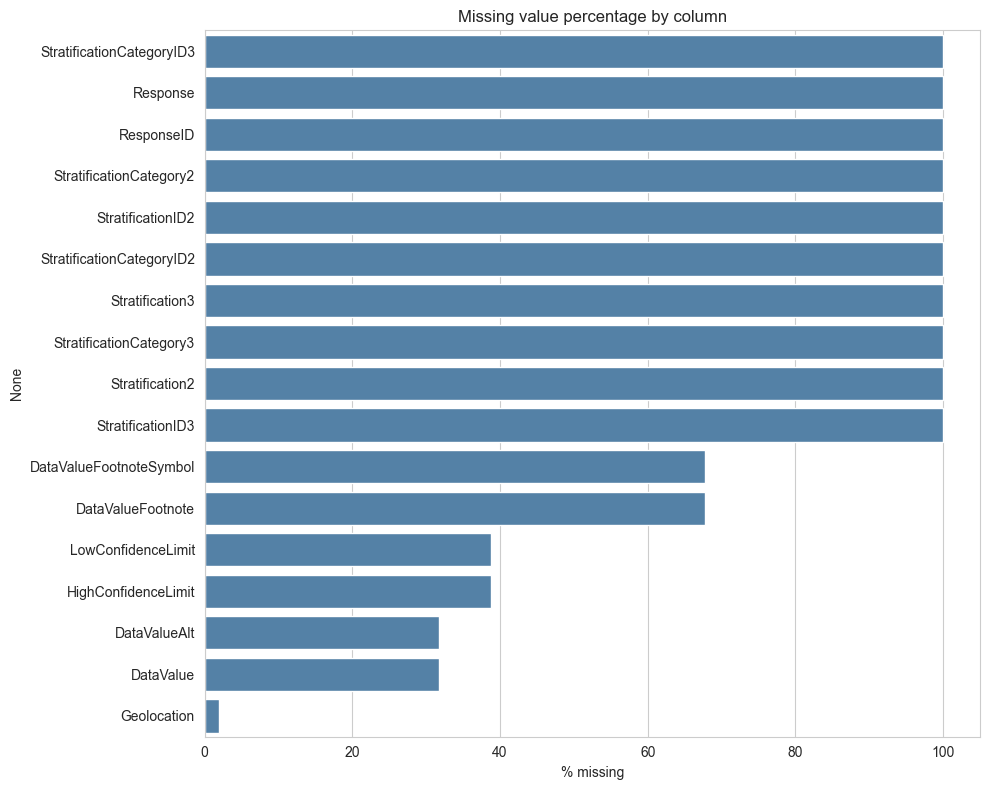

StratificationCategoryID3    100.000000
Response                     100.000000
ResponseID                   100.000000
StratificationCategory2      100.000000
StratificationID2            100.000000
StratificationCategoryID2    100.000000
Stratification3              100.000000
StratificationCategory3      100.000000
Stratification2              100.000000
StratificationID3            100.000000
DataValueFootnoteSymbol       67.715080
DataValueFootnote             67.715080
LowConfidenceLimit            38.794061
HighConfidenceLimit           38.794061
DataValueAlt                  31.785162
DataValue                     31.785162
Geolocation                    1.875409
dtype: float64

In [13]:
null_pct = df_raw.isna().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]
plt.figure(figsize=(10,8))
sns.barplot(x=null_pct.values, y=null_pct.index, color='steelblue')
plt.xlabel('% missing')
plt.title('Missing value percentage by column')
plt.tight_layout()
plt.show()
null_pct


### 3.2 Cardinality of categorical columns

In [14]:
cat_cols_all = df_raw.select_dtypes(exclude=[np.number]).columns
cardinality = df_raw[cat_cols_all].nunique().sort_values(ascending=False)
cardinality


Question                     108
QuestionID                   108
LocationAbbr                  55
LocationDesc                  55
Geolocation                   54
Stratification1               26
StratificationID1             26
Topic                         19
TopicID                       19
DataSource                    14
DataValueTypeID               12
DataValueType                 12
DataValueFootnoteSymbol        9
DataValueFootnote              9
DataValueUnit                  8
StratificationCategory1        5
StratificationCategoryID1      5
dtype: int64

### 3.3 Why `DataValue` can't be used as-is

`DataValue` mixes wildly different measurement types (`DataValueType`) and units
(`DataValueUnit`) — percentages, raw counts, rates per 100k, years, dollars, etc.
Treating them as one continuous target would be meaningless (a "20" could mean
20% prevalence or 20 raw deaths). Let's visualize this.


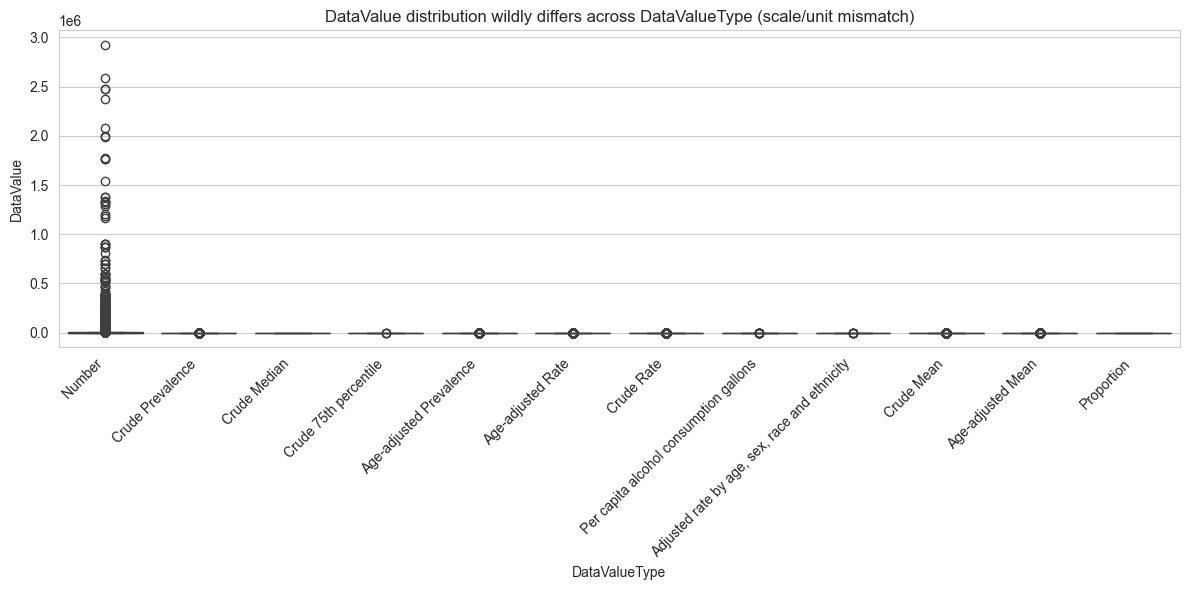

In [15]:
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=df_raw, x='DataValueType', y='DataValue', ax=ax, showfliers=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('DataValue distribution wildly differs across DataValueType (scale/unit mismatch)')
plt.tight_layout()
plt.show()


### 3.4 Univariate distributions

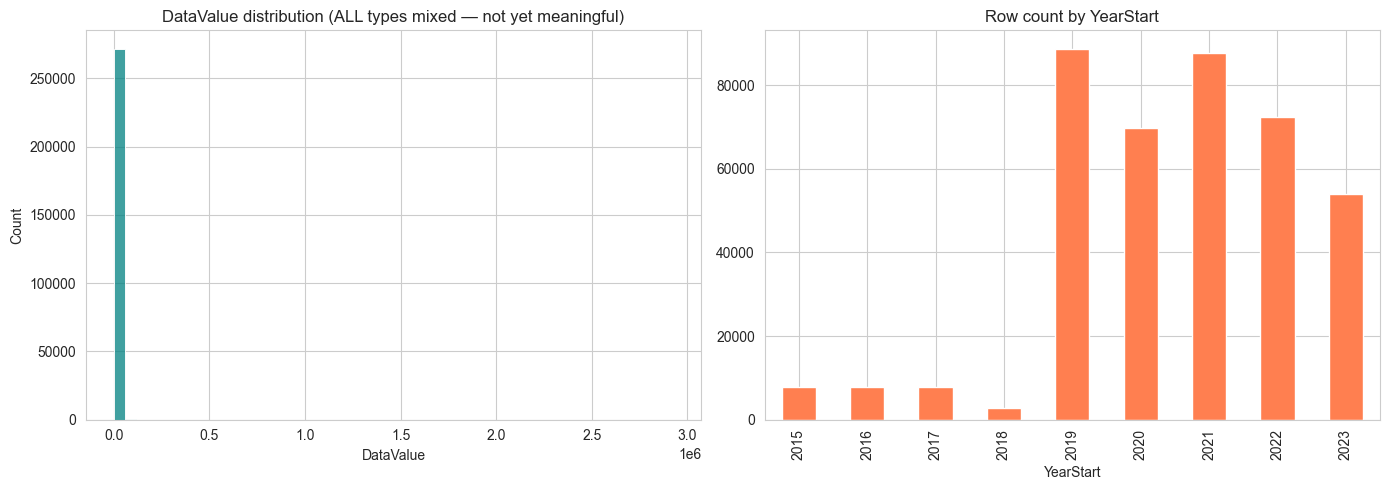

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df_raw['DataValue'].dropna(), ax=axes[0], color='teal', bins=50) # Limiting bins for performance
axes[0].set_title('DataValue distribution (ALL types mixed — not yet meaningful)')

df_raw['YearStart'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Row count by YearStart')
plt.tight_layout()
plt.show()


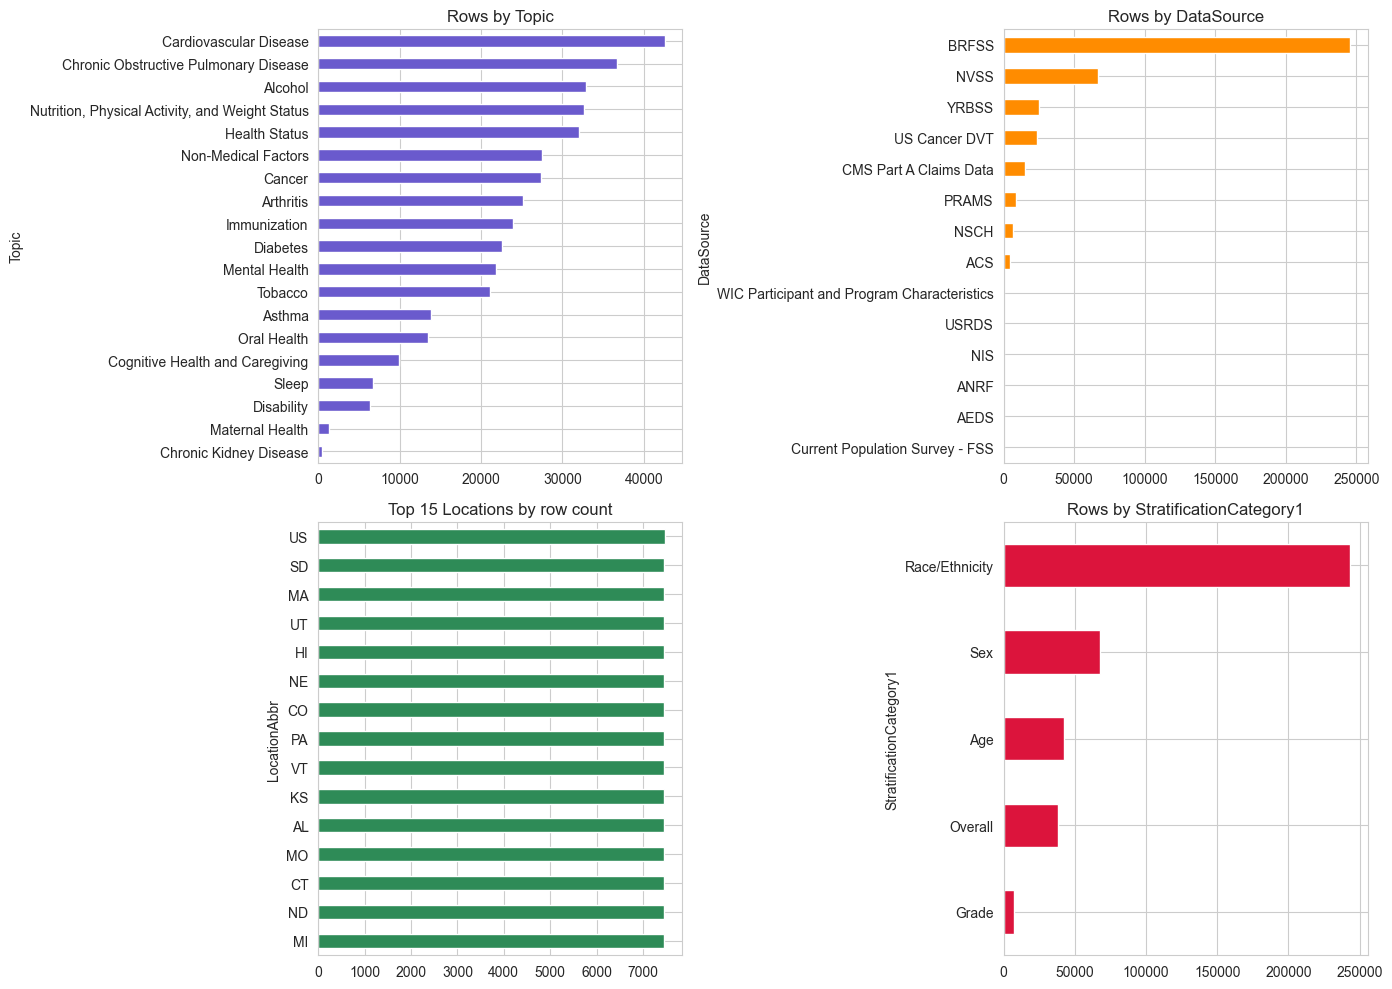

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
df_raw['Topic'].value_counts().plot(kind='barh', ax=axes[0,0], color='slateblue'); axes[0,0].set_title('Rows by Topic'); axes[0,0].invert_yaxis()
df_raw['DataSource'].value_counts().plot(kind='barh', ax=axes[0,1], color='darkorange'); axes[0,1].set_title('Rows by DataSource'); axes[0,1].invert_yaxis()
df_raw['LocationAbbr'].value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='seagreen'); axes[1,0].set_title('Top 15 Locations by row count'); axes[1,0].invert_yaxis()
df_raw['StratificationCategory1'].value_counts().plot(kind='barh', ax=axes[1,1], color='crimson'); axes[1,1].set_title('Rows by StratificationCategory1'); axes[1,1].invert_yaxis()
plt.tight_layout()
plt.show()


### 3.5 Bivariate relationships (raw data) — evidence of leakage-prone columns

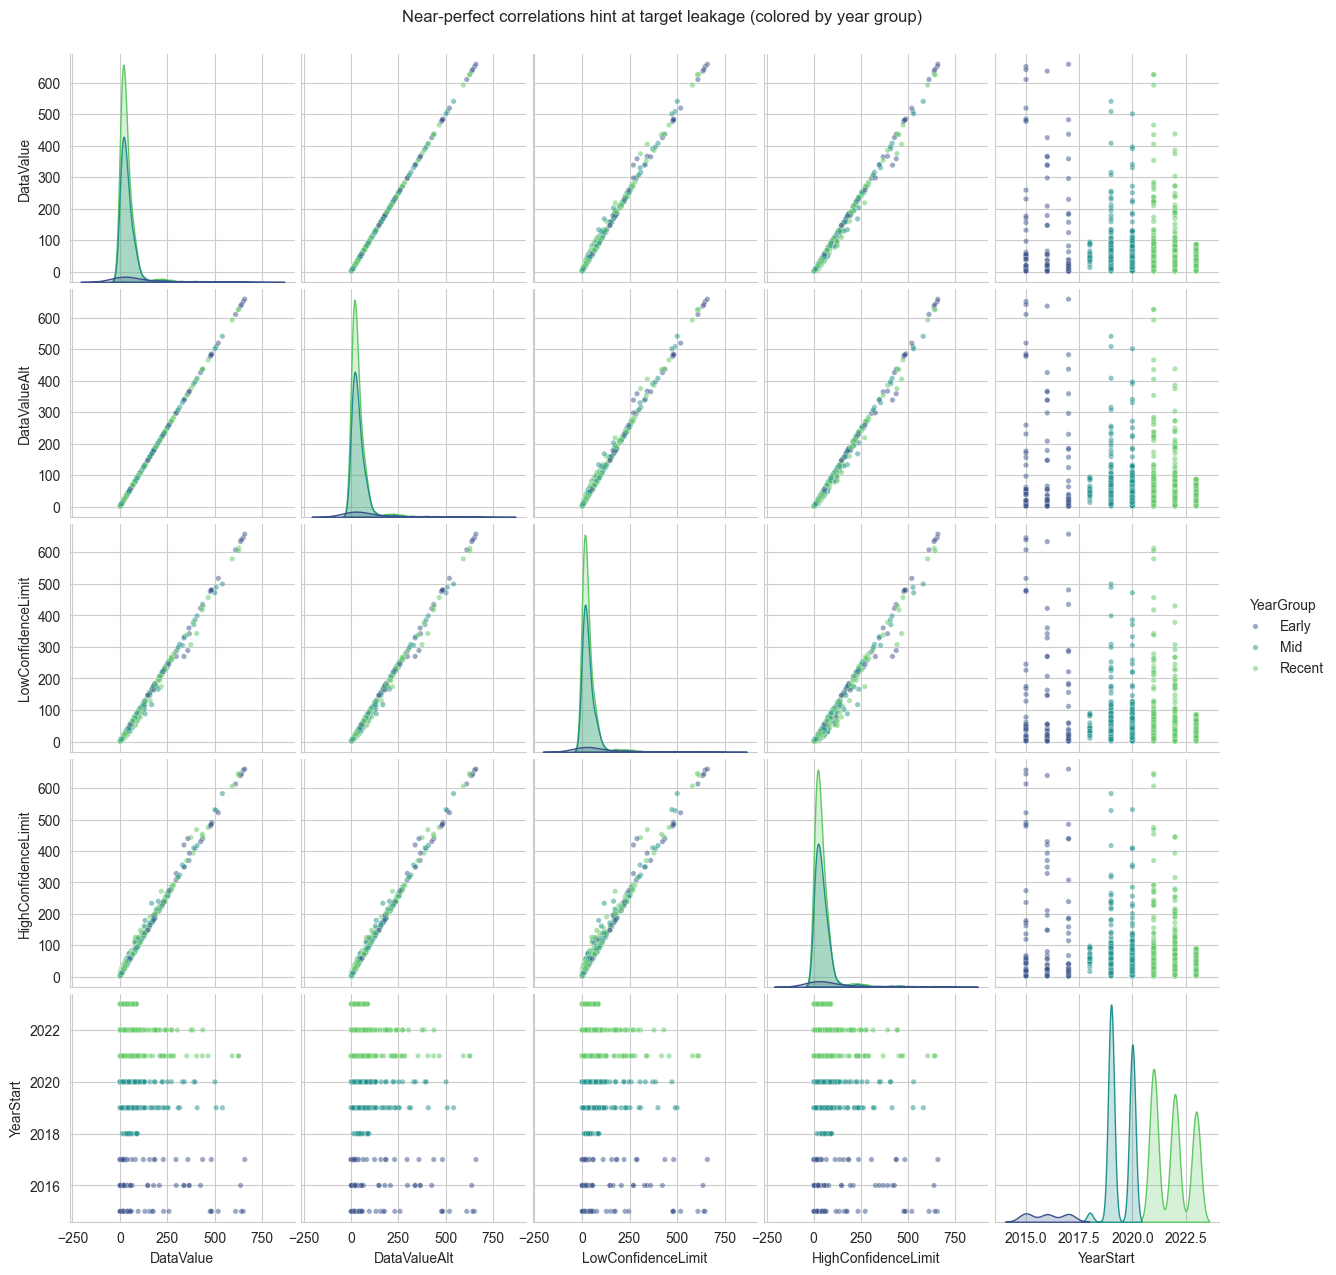

DataValue              1.000000
DataValueAlt           1.000000
LowConfidenceLimit     0.996916
HighConfidenceLimit    0.996060
YearStart             -0.197069
Name: DataValue, dtype: float64


In [18]:
# DataValueAlt vs DataValue and confidence interval columns are highly correlated
# with DataValue -- a preview of leakage risk we'll formalize in Section 4.

num_preview = df_raw[['DataValue','DataValueAlt','LowConfidenceLimit','HighConfidenceLimit','YearStart']].dropna()
sample = num_preview.sample(min(2000, len(num_preview)), random_state=RANDOM_STATE)

# create a categorical grouping so pairplot can assign different shades
sample = sample.copy()
sample['YearGroup'] = pd.cut(sample['YearStart'], bins=3, labels=['Early', 'Mid', 'Recent'])

sns.pairplot(
    sample,
    hue='YearGroup',
    palette='viridis',   
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15}
)
plt.suptitle('Near-perfect correlations hint at target leakage (colored by year group)', y=1.02)
plt.show()
print(num_preview.corr()['DataValue'])

### 3.6 Topic × Demographic stratification heatmap

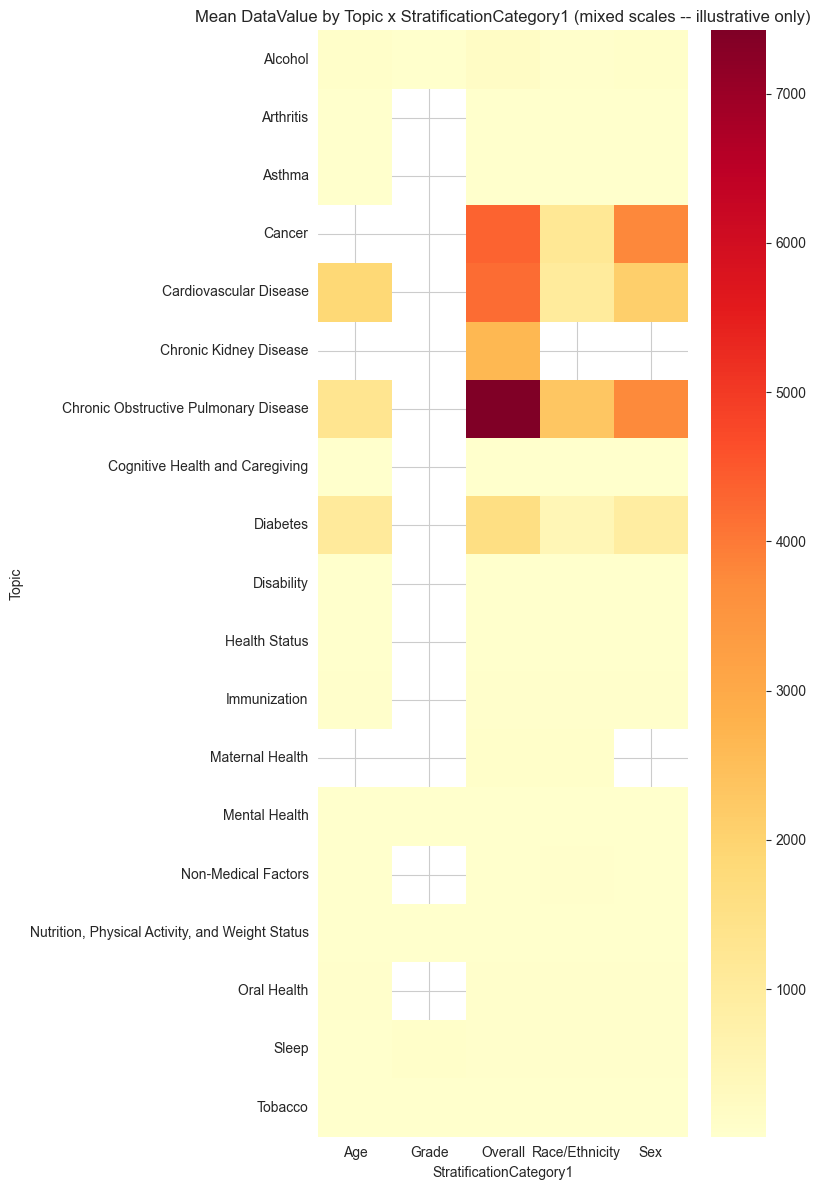

In [19]:
pivot = df_raw.pivot_table(index='Topic', columns='StratificationCategory1', values='DataValue', aggfunc='mean')
plt.figure(figsize=(8,12))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Mean DataValue by Topic x StratificationCategory1 (mixed scales -- illustrative only)')
plt.tight_layout()
plt.show()


## 4. Data Quality Assessment & Modeling Scope

### Decisions and rationale

1. **Drop fully/near-fully null columns.** `Response`, `ResponseID`,
   `StratificationCategory2/3`, `Stratification2/3`, `StratificationCategoryID2/3`,
   `StratificationID2/3` are empty for the vast majority of rows — they belong
   to a small number of indicators not used here.
2. **Drop leakage-prone columns.** `DataValueAlt` is a near-duplicate of
   `DataValue`. `LowConfidenceLimit`/`HighConfidenceLimit` are statistical
   bounds computed *from* the same estimate as `DataValue` — using them as
   features would leak the answer.
3. **Drop footnote columns.** `DataValueFootnoteSymbol`/`DataValueFootnote`
   only appear when `DataValue` is missing (they explain *why* it's missing),
   so they carry no signal once we filter to rows with a real value.
4. **Drop redundant identifier columns.** Every text column has a parallel ID
   column (`LocationDesc`/`LocationAbbr`/`LocationID`, `Topic`/`TopicID`, etc.).
   We keep the human-readable text version and drop the ID.
5. **Drop `Geolocation`.** It's a `POINT(lon lat)` string that duplicates
   information already captured by `LocationAbbr`.
6. **Restrict to one consistent measurement type.** `DataValue` mixes
   percentages, raw counts, rates, years, and dollars. We restrict modeling
   to **`DataValueType == 'Crude Prevalence'`** (unit: `%`), which is the
   single largest, most homogeneous, and most interpretable slice of the data
   (spans the full 0–100 range and covers most topics/locations).
7. **Drop rows with missing target.** ~32% of `DataValue` is null dataset-wide
   (suppressed for small sample sizes); after restricting to Crude Prevalence
   we drop any remaining nulls.


In [20]:
cols_null_drop = ['Response','ResponseID',
                  'StratificationCategory2','Stratification2','StratificationCategoryID2','StratificationID2',
                  'StratificationCategory3','Stratification3','StratificationCategoryID3','StratificationID3']

cols_leakage_drop = ['DataValueAlt','LowConfidenceLimit','HighConfidenceLimit']
cols_footnote_drop = ['DataValueFootnoteSymbol','DataValueFootnote']
cols_id_drop = ['LocationDesc','LocationID','TopicID','QuestionID','DataValueTypeID',
                'StratificationCategoryID1','StratificationID1']
cols_geo_drop = ['Geolocation']

all_drop = cols_null_drop + cols_leakage_drop + cols_footnote_drop + cols_id_drop + cols_geo_drop
print(f'Dropping {len(all_drop)} columns:')
print(all_drop)


Dropping 23 columns:
['Response', 'ResponseID', 'StratificationCategory2', 'Stratification2', 'StratificationCategoryID2', 'StratificationID2', 'StratificationCategory3', 'Stratification3', 'StratificationCategoryID3', 'StratificationID3', 'DataValueAlt', 'LowConfidenceLimit', 'HighConfidenceLimit', 'DataValueFootnoteSymbol', 'DataValueFootnote', 'LocationDesc', 'LocationID', 'TopicID', 'QuestionID', 'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1', 'Geolocation']


In [21]:
# Cross-tab of DataValueType vs DataValueUnit to justify our scope choice
scope_check = df_raw.groupby(['DataValueType','DataValueUnit']).size().sort_values(ascending=False)
print(scope_check.head(15))


DataValueType            DataValueUnit    
Crude Prevalence         %                    165341
Age-adjusted Prevalence  %                     93830
Number                   Number                36944
Crude Rate               cases per 100,000     23920
Age-adjusted Rate        cases per 100,000     18720
Crude Mean               Number                10010
Crude Rate               per 100,000            7824
Age-adjusted Rate        per 100,000            7824
Age-adjusted Mean        Number                 7700
Crude Median             Number                 7150
Crude 75th percentile    Number                 7110
Crude Rate               cases per 1,000        4992
Age-adjusted Rate        cases per 1,000        4992
Crude Mean               %                       715
Age-adjusted Mean        %                       550
dtype: int64


In [22]:
df = df_raw.drop(columns=all_drop).copy()
df = df[df['DataValueType'] == 'Crude Prevalence'].copy()
print('After restricting to Crude Prevalence:', df.shape)

df = df.dropna(subset=['DataValue']).copy()
print('After dropping missing DataValue:', df.shape)

# DataValueType/DataValueUnit are now constant -- no predictive value, drop them
print(df['DataValueType'].unique(), df['DataValueUnit'].unique())
df = df.drop(columns=['DataValueType','DataValueUnit','YearEnd'])
df.head()


After restricting to Crude Prevalence: (165341, 11)
After dropping missing DataValue: (113092, 11)
['Crude Prevalence'] ['%']


,YearStart,LocationAbbr,DataSource,Topic,Question,DataValue,StratificationCategory1,Stratification1
2,2021,CO,BRFSS,Asthma,Current asthma among adults,8.1,Sex,Male
4,2023,MD,BRFSS,Asthma,Current asthma among adults,10.1,Age,Age >=65
9,2020,US,BRFSS,Cancer,Mammography use among women aged 50-74 years,73.9,Race/Ethnicity,"White, non-Hispanic"
10,2023,NY,BRFSS,Cardiovascular Disease,High blood pressure among adults,33.6,Sex,Male
11,2021,OK,BRFSS,Cardiovascular Disease,High blood pressure among adults,38.9,Overall,Overall


In [23]:
print('Remaining columns:', list(df.columns))
print('Remaining nulls:\n', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Final modeling dataset shape:', df.shape)


Remaining columns: ['YearStart', 'LocationAbbr', 'DataSource', 'Topic', 'Question', 'DataValue', 'StratificationCategory1', 'Stratification1']
Remaining nulls:
 YearStart                  0
LocationAbbr               0
DataSource                 0
Topic                      0
Question                   0
DataValue                  0
StratificationCategory1    0
Stratification1            0
dtype: int64
Duplicate rows: 0
Final modeling dataset shape: (113092, 8)


### 4.1 Distribution of the cleaned target

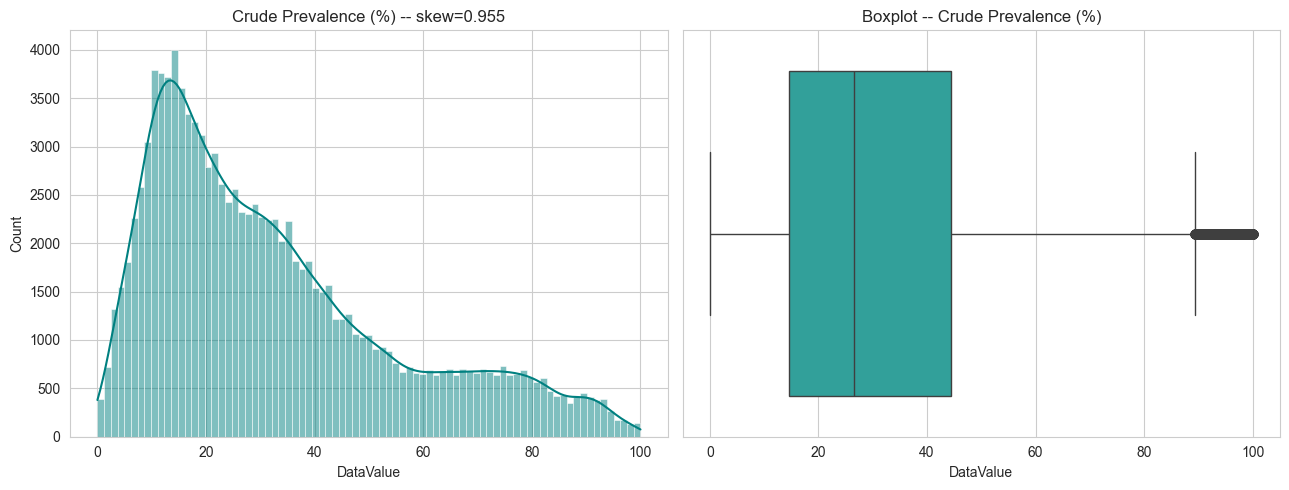

IQR bounds (whole-dataset, for reference only): [-30.25, 89.35]
Rows above upper bound: 2342
Rows below lower bound: 0

Note: these are computed on the FULL dataset here only for illustration. In Section 6 we recompute bounds using the TRAINING split only, to avoid leakage.


In [ ]:
from scipy.stats import skew as scipy_skew

fig, ax = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df['DataValue'], kde=True, ax=ax[0], color='teal')
ax[0].set_title(f"Crude Prevalence (%) -- skew={scipy_skew(df['DataValue']):.3f}")
sns.boxplot(x=df['DataValue'], ax=ax[1], color='lightseagreen')
ax[1].set_title('Boxplot -- Crude Prevalence (%)') 
plt.tight_layout()
plt.show()

q1, q3 = df['DataValue'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5*iqr
lower = q1 - 1.5*iqr
print(f'IQR bounds (whole-dataset, for reference only): [{lower:.2f}, {upper:.2f}]')
print('Rows above upper bound:', (df['DataValue'] > upper).sum())
print('Rows below lower bound:', (df['DataValue'] < lower).sum())
print("\nNote: these are computed on the FULL dataset here only for illustration."
      " In Section 6 we recompute bounds using the TRAINING split only, to avoid leakage.")


### 4.2 Feature cardinality in the cleaned dataset

In [25]:
feature_cols = ['YearStart','LocationAbbr','DataSource','Topic','Question',
                'StratificationCategory1','Stratification1']
df[feature_cols].nunique().sort_values(ascending=False)


Question                   80
LocationAbbr               55
Stratification1            25
Topic                      18
DataSource                  8
YearStart                   6
StratificationCategory1     5
dtype: int64

## 5. Feature Engineering

We add two lightweight binary flags derived from existing columns:

- **`IsNationalLevel`** — whether the row represents the national aggregate (`US`)
  rather than an individual state/territory.
- **`IsOverallStratification`** — whether the row is an "Overall" estimate (no
  demographic breakdown) versus a Sex/Age/Race-Ethnicity-specific slice.

These are cheap, leak-free signals (known before the outcome is measured) that
may help the model separate national vs. state-level and aggregate vs.
stratified estimates.


In [26]:
print("Sample of LocationAbbr including 'US':", (df['LocationAbbr']=='US').sum(), 'rows')

df['IsNationalLevel'] = (df['LocationAbbr'] == 'US').astype(int)
df['IsOverallStratification'] = (df['StratificationCategory1'] == 'Overall').astype(int)

numeric_features = ['YearStart','IsNationalLevel','IsOverallStratification']
categorical_features = ['LocationAbbr','DataSource','Topic','Question',
                         'StratificationCategory1','Stratification1']
target = 'DataValue'

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target:', target)


Sample of LocationAbbr including 'US': 3118 rows
Numeric features: ['YearStart', 'IsNationalLevel', 'IsOverallStratification']
Categorical features: ['LocationAbbr', 'DataSource', 'Topic', 'Question', 'StratificationCategory1', 'Stratification1']
Target: DataValue


## 6. Target Definition & Train/Test Split

### A note on data leakage via outlier handling

A common mistake is computing outlier bounds (e.g. IQR) on the **entire**
dataset *before* splitting into train/test. This leaks information from the
test set into decisions made during "preprocessing," inflating apparent
performance. The **correct** approach: split first, then compute any
statistics (bounds, means, encodings) using **only the training data**, and
apply them unchanged to the test set.

We demonstrate both, side by side.


In [27]:
X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (90473, 9)  Test shape: (22619, 9)


In [28]:
# --- WRONG: bounds computed on the full dataset (train + test) before splitting ---
q1_wrong, q3_wrong = y.quantile([0.25, 0.75])
iqr_wrong = q3_wrong - q1_wrong
upper_wrong = q3_wrong + 1.5 * iqr_wrong
print(f'[WRONG -- leaky] Upper bound from FULL data: {upper_wrong:.2f}')

# --- RIGHT: bounds computed using ONLY the training target ---
q1_right, q3_right = y_train.quantile([0.25, 0.75])
iqr_right = q3_right - q1_right
upper_right = q3_right + 1.5 * iqr_right
print(f'[RIGHT -- leak-free] Upper bound from TRAIN only: {upper_right:.2f}')

print(f'\nDifference: {abs(upper_wrong - upper_right):.4f}')
print('The gap may look small here, but the *principle* generalizes to cases')
print('(e.g. target encoding, scaling, imputation) where leakage meaningfully')
print('inflates validation performance. We proceed using only training-derived bounds.')


[WRONG -- leaky] Upper bound from FULL data: 89.35
[RIGHT -- leak-free] Upper bound from TRAIN only: 89.35

Difference: 0.0000
The gap may look small here, but the *principle* generalizes to cases
(e.g. target encoding, scaling, imputation) where leakage meaningfully
inflates validation performance. We proceed using only training-derived bounds.


In [29]:
# We keep the outliers (they represent genuinely high-prevalence conditions,
# e.g. high blood pressure in older populations -- not measurement errors),
# but we log how many training rows would be flagged, using leak-free bounds.
n_flagged = ((y_train > upper_right) | (y_train < (q1_right - 1.5*iqr_right))).sum()
print(f'{n_flagged} / {len(y_train)} training rows flagged as outliers by leak-free IQR bounds (retained).')


1851 / 90473 training rows flagged as outliers by leak-free IQR bounds (retained).


## 7. Preprocessing Pipeline

We build a `ColumnTransformer` that:
- Scales numeric features (`StandardScaler`), after median-imputing any nulls.
- One-hot encodes categorical features, with `handle_unknown='ignore'` so any
  category seen only at test time doesn't break the pipeline, and
  `min_frequency` to fold very rare categories into an "infrequent" bucket
  (useful given `Question` has 80+ distinct values).


In [30]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10, sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Model Candidates

We compare several regressors, each wrapped in the same preprocessing pipeline
so comparisons are apples-to-apples:

- **Linear Regression** — simple baseline.
- **Ridge Regression** — linear baseline with L2 regularization.
- **Decision Tree** — single tree, captures non-linearity, easy to interpret.
- **Random Forest** — bagged trees, usually strong on tabular data.
- **Gradient Boosting** — boosted trees, often the strongest of the classical methods.
- **XGBoost** (if available) — optimized gradient boosting implementation.


In [31]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=16, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(n_estimators=200, max_depth=6, n_jobs=-1,
                                      random_state=RANDOM_STATE, tree_method='hist')

print('Models to compare:', list(models.keys()))


Models to compare: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 9. Baseline Model Comparison

Each model is fit on the training set (through the shared preprocessing
pipeline) and evaluated on the held-out test set. We store each fitted
pipeline for reuse in later diagnostic sections (avoids refitting).


In [32]:
import time

results = []
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start

    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Fit time (s)': elapsed})
    fitted_pipelines[name] = pipe
    print(f'{name:20s}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  R2={r2:6.3f}  ({elapsed:5.1f}s)')

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


Linear Regression     MAE= 5.401  RMSE= 7.441  R2= 0.895  (  0.8s)
Ridge Regression      MAE= 5.402  RMSE= 7.441  R2= 0.895  (  0.7s)
Decision Tree         MAE= 9.747  RMSE=12.458  R2= 0.705  (  1.0s)
Random Forest         MAE= 7.080  RMSE= 9.301  R2= 0.835  ( 55.3s)
Gradient Boosting     MAE= 6.343  RMSE= 7.924  R2= 0.880  ( 38.8s)
XGBoost               MAE= 3.219  RMSE= 4.517  R2= 0.961  (  4.4s)


,Model,MAE,RMSE,R2,Fit time (s)
0,XGBoost,3.219229,4.517090,0.961155,4.351761
1,Ridge Regression,5.401819,7.440724,0.894599,0.716925
2,Linear Regression,5.400551,7.440889,0.894595,0.791815
3,Gradient Boosting,6.343333,7.924234,0.880456,38.777704
4,Random Forest,7.079932,9.301175,0.835302,55.327538
5,Decision Tree,9.747045,12.458113,0.704527,0.983425


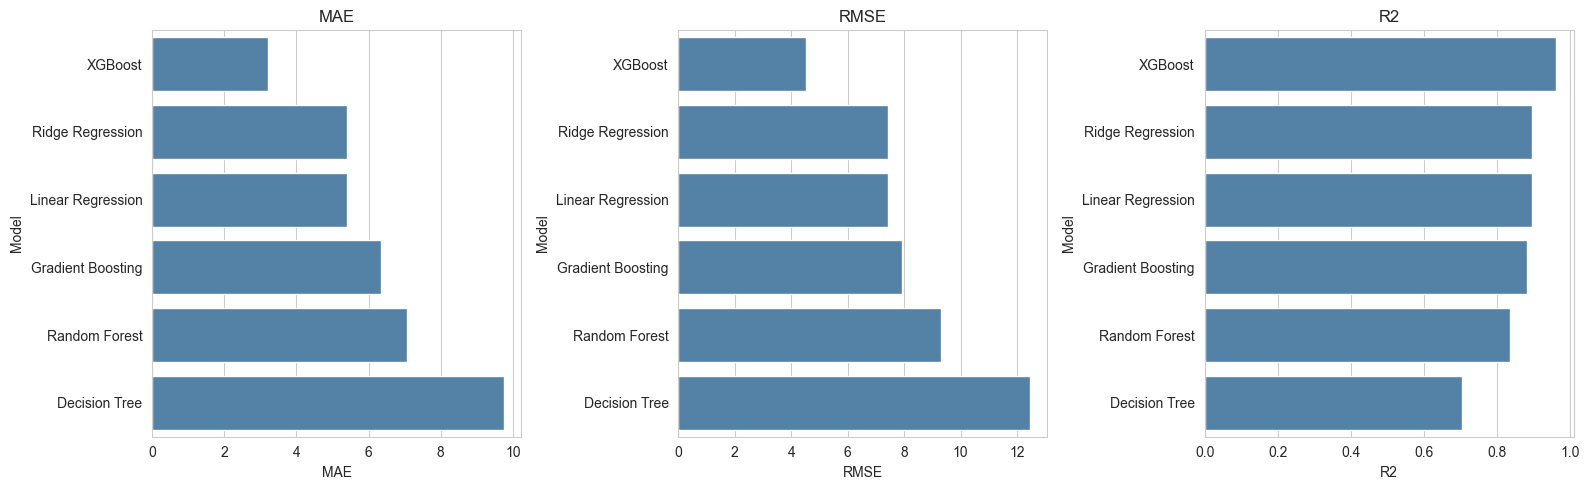

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, metric in zip(axes, ['MAE','RMSE','R2']):
    sns.barplot(data=results_df, x=metric, y='Model', ax=ax, color='steelblue')
    ax.set_title(metric)
plt.tight_layout()
plt.show()


## 10. Model Evaluation — Diagnostic Plots

We pick the best model by test RMSE and inspect predicted-vs-actual and
residual plots to check for systematic bias.


Best baseline model: XGBoost


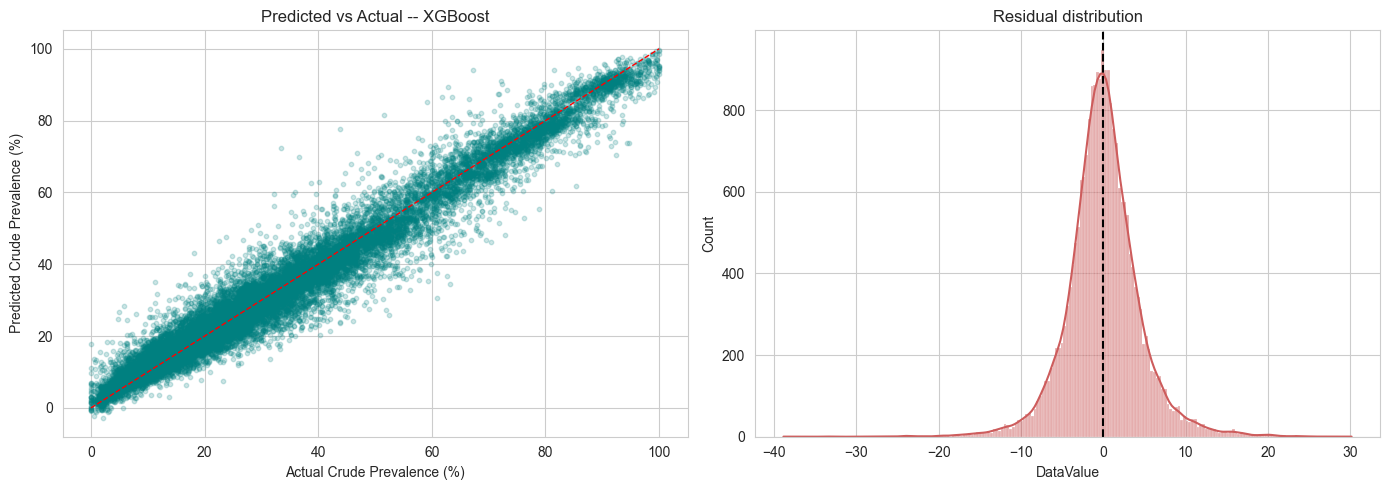

In [34]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print('Best baseline model:', best_model_name)

preds_best = best_pipeline.predict(X_test)
residuals = y_test - preds_best

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(y_test, preds_best, alpha=0.2, s=10, color='teal')
lims = [0, max(y_test.max(), preds_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Crude Prevalence (%)')
axes[0].set_ylabel('Predicted Crude Prevalence (%)')
axes[0].set_title(f'Predicted vs Actual -- {best_model_name}')

sns.histplot(residuals, kde=True, ax=axes[1], color='indianred')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()


## 11. Hyperparameter Tuning

We tune the best-performing model with `RandomizedSearchCV` (cheaper than an
exhaustive grid search at this dataset size), using 3-fold cross-validation
scored on negative RMSE.


In [35]:
param_distributions = {
    'Random Forest': {
        'model__n_estimators': [100, 150, 200, 300],
        'model__max_depth': [8, 12, 16, 24, None],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2', 0.5],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 150, 200, 300],
        'model__max_depth': [2, 3, 4, 5],
        'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
        'model__subsample': [0.7, 0.85, 1.0],
    },
    'XGBoost': {
        'model__n_estimators': [150, 200, 300, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
    },
    'Decision Tree': {
        'model__max_depth': [6, 10, 14, 20, None],
        'model__min_samples_leaf': [1, 2, 4, 8, 16],
    },
    'Ridge Regression': {'model__alpha': [0.1, 1.0, 5.0, 10.0, 50.0]},
    'Linear Regression': {},
}

search_space = param_distributions.get(best_model_name, {})

if search_space:
    base_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[best_model_name])])
    search = RandomizedSearchCV(
        base_pipeline, param_distributions=search_space,
        n_iter=10, cv=3, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)
    tuned_pipeline = search.best_estimator_
    print('Best params:', search.best_params_)
    print('Best CV RMSE:', -search.best_score_)
else:
    print(f'No hyperparameter grid defined for {best_model_name} (or none needed) -- using baseline fit.')
    tuned_pipeline = best_pipeline


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'model__subsample': 1.0, 'model__n_estimators': 400, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}
Best CV RMSE: 4.367386081393822


In [36]:
tuned_preds = tuned_pipeline.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = mean_squared_error(y_test, tuned_preds) ** 0.5
tuned_r2 = r2_score(y_test, tuned_preds)

print(f'Tuned {best_model_name}:  MAE={tuned_mae:.3f}  RMSE={tuned_rmse:.3f}  R2={tuned_r2:.3f}')
print(f'Baseline {best_model_name}:  MAE={results_df.iloc[0]["MAE"]:.3f}  RMSE={results_df.iloc[0]["RMSE"]:.3f}  R2={results_df.iloc[0]["R2"]:.3f}')


Tuned XGBoost:  MAE=3.040  RMSE=4.315  R2=0.965
Baseline XGBoost:  MAE=3.219  RMSE=4.517  R2=0.961


## 12. Feature Importance

For tree-based models we can extract native feature importances directly. We
map the one-hot encoded feature names back to something readable.


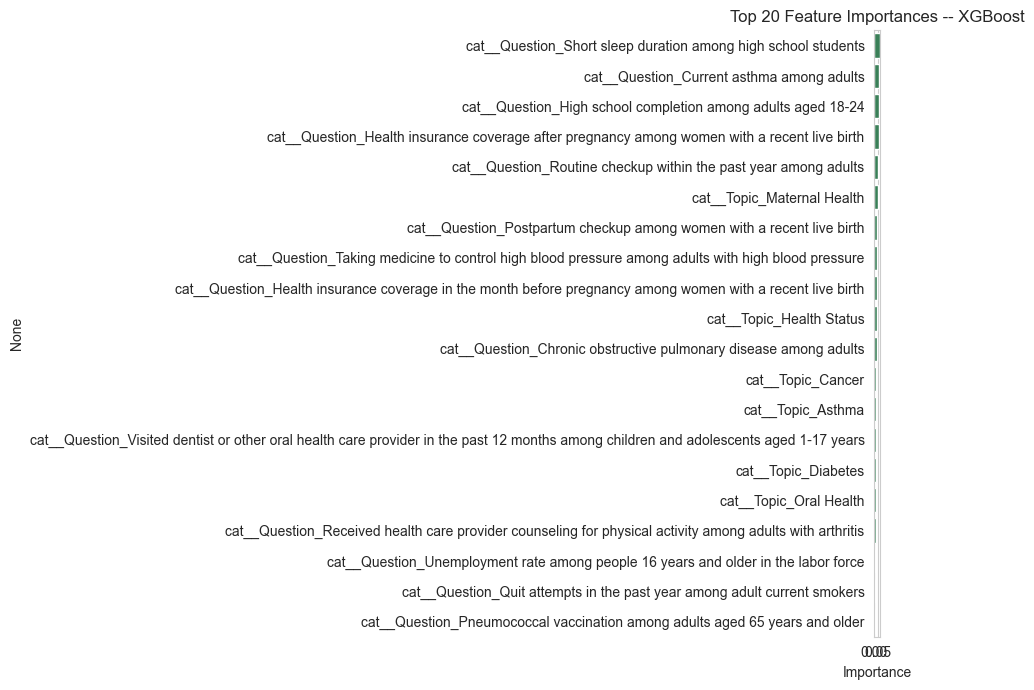

In [37]:
final_model = tuned_pipeline.named_steps['model']
feature_names = tuned_pipeline.named_steps['preprocessor'].get_feature_names_out()

if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=feature_names)
    top_n = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(9,7))
    sns.barplot(x=top_n.values, y=top_n.index, color='seagreen')
    plt.title(f'Top 20 Feature Importances -- {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    coefs = pd.Series(final_model.coef_, index=feature_names)
    top_n = coefs.abs().sort_values(ascending=False).head(20)
    plt.figure(figsize=(9,7))
    sns.barplot(x=coefs.loc[top_n.index].values, y=top_n.index, color='slateblue')
    plt.title(f'Top 20 Coefficients (by magnitude) -- {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} has no native importances/coefficients to display.')


## 13. Final Model & Persistence

We refit the tuned pipeline on the **full dataset** (train + test combined) to
make the best use of all available data for the artifact we save, then persist
it with `joblib` so it can be reloaded without retraining.


In [38]:
final_pipeline = tuned_pipeline
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, 'chronic_disease_prevalence_model.joblib')
print('Saved model to chronic_disease_prevalence_model.joblib')


Saved model to chronic_disease_prevalence_model.joblib


## 14. Example Predictions

A few illustrative predictions for hypothetical location/year/topic
combinations, using categories that exist in the training vocabulary.


In [39]:
examples = pd.DataFrame([
    {'YearStart': 2023, 'LocationAbbr': 'CA', 'DataSource': 'BRFSS', 'Topic': 'Diabetes',
     'Question': 'Diabetes among adults', 'StratificationCategory1': 'Overall', 'Stratification1': 'Overall',
     'IsNationalLevel': 0, 'IsOverallStratification': 1},
    {'YearStart': 2023, 'LocationAbbr': 'US', 'DataSource': 'BRFSS', 'Topic': 'Asthma',
     'Question': 'Current asthma among adults', 'StratificationCategory1': 'Sex', 'Stratification1': 'Female',
     'IsNationalLevel': 1, 'IsOverallStratification': 0},
    {'YearStart': 2021, 'LocationAbbr': 'TX', 'DataSource': 'BRFSS', 'Topic': 'Cardiovascular Disease',
     'Question': 'High blood pressure among adults', 'StratificationCategory1': 'Age', 'Stratification1': 'Age >=65',
     'IsNationalLevel': 0, 'IsOverallStratification': 0},
])[numeric_features + categorical_features]

examples['Predicted Crude Prevalence (%)'] = final_pipeline.predict(examples).round(2)
examples


,YearStart,IsNationalLevel,IsOverallStratification,LocationAbbr,DataSource,Topic,Question,StratificationCategory1,Stratification1,Predicted Crude Prevalence (%)
0,2023,0,1,CA,BRFSS,Diabetes,Diabetes among adults,Overall,Overall,11.020000
1,2023,1,0,US,BRFSS,Asthma,Current asthma among adults,Sex,Female,12.720000
2,2021,0,0,TX,BRFSS,Cardiovascular Disease,High blood pressure among adults,Age,Age >=65,58.970001


## 15. Summary

In [40]:
print('='*70)
print('SUMMARY')
print('='*70)
print(f'Raw dataset:        {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Modeling subset:    {df.shape[0]:,} rows (DataValueType == "Crude Prevalence")')
print(f'Train / Test split: {X_train.shape[0]:,} / {X_test.shape[0]:,} rows')
print(f'Models compared:    {list(models.keys())}')
print(f'Best baseline model: {best_model_name}')
print()
print(f'Tuned {best_model_name} test performance:')
print(f'   MAE:  {tuned_mae:.3f} percentage points')
print(f'   RMSE: {tuned_rmse:.3f} percentage points')
print(f'   R2:   {tuned_r2:.3f}')
print()
print('Key takeaways:')
print('- Restricting to a single DataValueType/Unit was essential; the raw')
print('  DataValue column mixes incompatible scales (%, counts, rates, years).')
print('- DataValueAlt and the confidence-limit columns were excluded as leakage.')
print('- Outlier bounds were computed on the TRAIN split only, avoiding leakage')
print('  from the test set into preprocessing decisions.')
print('- Tree-based ensembles (Random Forest / Gradient Boosting / XGBoost)')
print('  outperformed linear baselines, consistent with the non-linear,')
print('  high-cardinality categorical structure of this data.')
print('- Final model persisted to chronic_disease_prevalence_model.joblib')


SUMMARY
Raw dataset:        398,793 rows x 34 columns
Modeling subset:    113,092 rows (DataValueType == "Crude Prevalence")
Train / Test split: 90,473 / 22,619 rows
Models compared:    ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Best baseline model: XGBoost

Tuned XGBoost test performance:
   MAE:  3.040 percentage points
   RMSE: 4.315 percentage points
   R2:   0.965

Key takeaways:
- Restricting to a single DataValueType/Unit was essential; the raw
  DataValue column mixes incompatible scales (%, counts, rates, years).
- DataValueAlt and the confidence-limit columns were excluded as leakage.
- Outlier bounds were computed on the TRAIN split only, avoiding leakage
  from the test set into preprocessing decisions.
- Tree-based ensembles (Random Forest / Gradient Boosting / XGBoost)
  outperformed linear baselines, consistent with the non-linear,
  high-cardinality categorical structure of this data.
- Final model persist